# K-Nearest Neighbor Classification Mini-Project
# **Dataset:** Breast Cancer Wisconsin (Diagnostic)
# This notebook demonstrates data preprocessing, feature scaling, hyperparameter tuning ($k$), 
# and comprehensive evaluation of a K-Nearest Neighbor (KNN) Classifier.

## 1. Importing dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set visual styles
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load and Explore the Dataset

###  Load dataset

In [2]:
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target, name='target')

print(f"Dataset Shape: {X.shape}")
print(f"Target Classes: {cancer_data.target_names} (0 = Malignant, 1 = Benign)")
print(f"Missing Values:\n{X.isnull().sum().sum()}")

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign'] (0 = Malignant, 1 = Benign)
Missing Values:
0


### Display class distribution

In [3]:
print("\nClass Distribution:")
print(y.value_counts(normalize=True))


Class Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## 3. Visualize Feature Distributions
Let's look at a few features to see their distributions and scales before normalization.

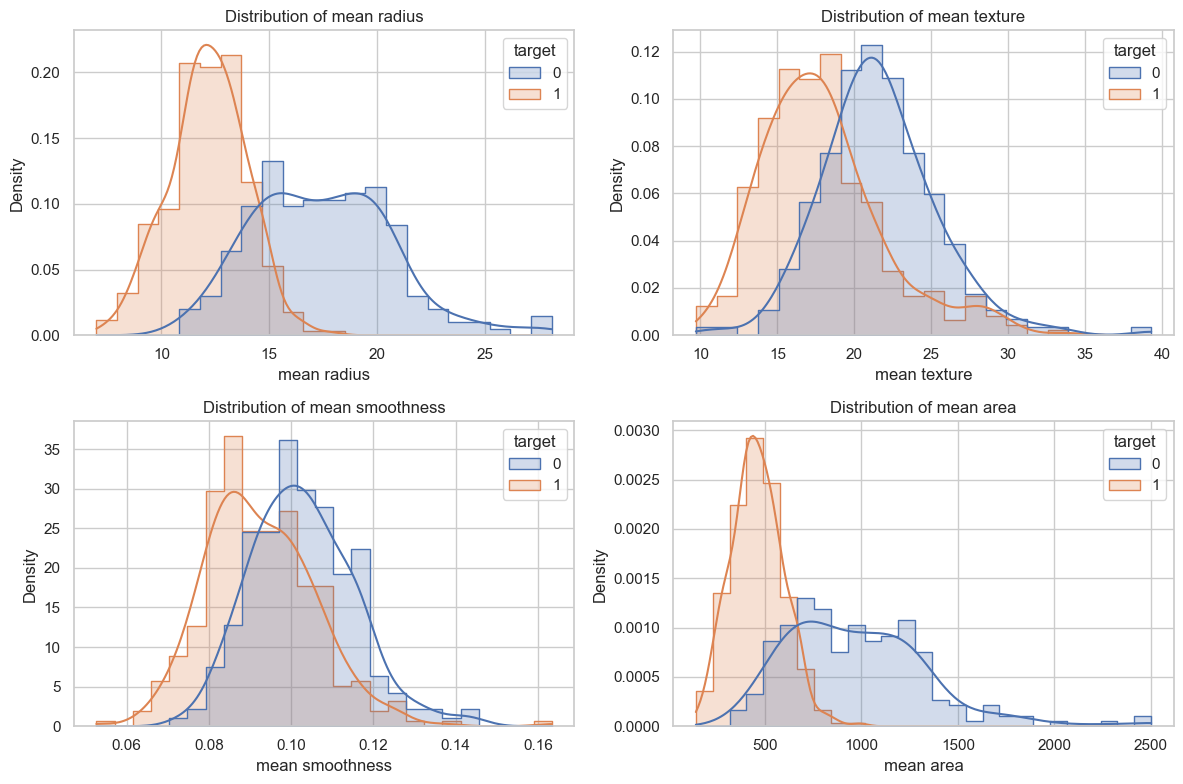

In [4]:
features_to_plot = ['mean radius', 'mean texture', 'mean smoothness', 'mean area']
plt.figure(figsize=(12, 8))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=X, x=col, hue=y, kde=True, element="step", stat="density", common_norm=False)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 4. Split Data into Training and Testing Sets

In [5]:
# 80/20 split with stratification to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


## 5. Apply Feature Scaling
KNN relies strictly on Euclidean distance. Features with larger ranges (like 'mean area') 
 will disproportionately dominate the distance metric if not scaled.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for verification
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("Mean of scaled features (First 5):", np.allclose(X_train_scaled_df.mean()[:5], 0))
print("Std of scaled features (First 5):", np.allclose(X_train_scaled_df.std()[:5], 1))

Mean of scaled features (First 5): True
Std of scaled features (First 5): False


## 6. Baseline KNN Model (Initial $k=5$)

In [7]:
baseline_knn = KNeighborsClassifier(n_neighbors=5)
baseline_knn.fit(X_train_scaled, y_train)
baseline_preds = baseline_knn.predict(X_test_scaled)

print(f"Baseline Test Accuracy (k=5): {accuracy_score(y_test, baseline_preds):.4f}")

Baseline Test Accuracy (k=5): 0.9561


## 7. Hyperparameter Tuning ($k$ validation via Cross-Validation)

Optimal k determined by Cross-Validation: 3


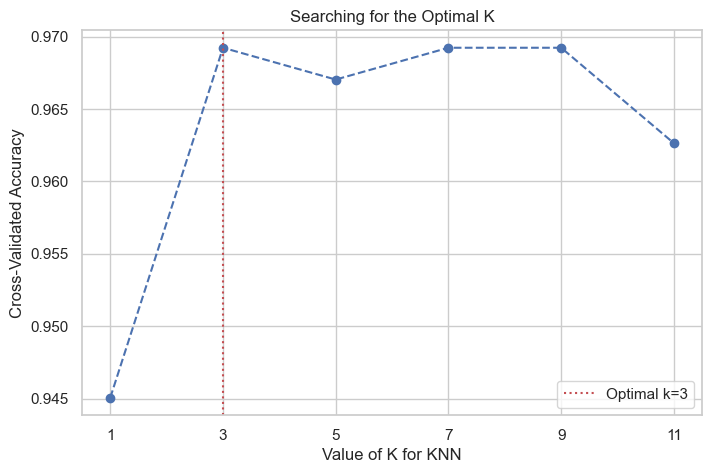

In [8]:
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

# Perform 5-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Identify optimal k
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal k determined by Cross-Validation: {optimal_k}")

# Plot k vs Accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='b')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Searching for the Optimal K')
plt.xticks(k_values)
plt.axvline(optimal_k, color='r', linestyle=':', label=f'Optimal k={optimal_k}')
plt.legend()
plt.show()

## 8. Train and Evaluate the Final Model

In [9]:
# Instantiate final model with the optimal k
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = final_knn.predict(X_test_scaled)

# Metrics calculation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("### Final Model Performance Metrics ###")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

### Final Model Performance Metrics ###
Accuracy:  0.9825
Precision: 0.9730
Recall:    1.0000
F1-Score:  0.9863

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Confusion Matrix Visualization

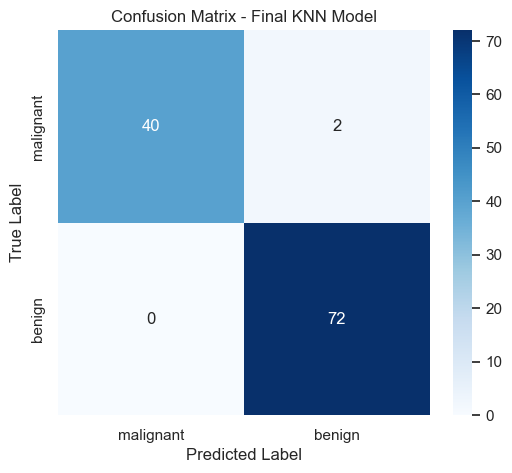

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cancer_data.target_names, 
            yticklabels=cancer_data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Final KNN Model')
plt.show()

## 9. Test Predictions on New Sample Data Points

In [11]:
#  Sample 1: Higher feature values (typically malignant characteristics)
#  Sample 2: Lower/average feature values (typically benign characteristics)
# Wrap the numpy array into a DataFrame and pass the original column names
sample_data_df = pd.DataFrame(
    [
        X_train.mean() + (X_train.std() * 1.5),
        X_train.mean() - (X_train.std() * 0.5)
    ],
    columns=X_train.columns # This fixes the warning!
)

# CRITICAL: Scale the sample data using the fitted scaler
sample_data_scaled = scaler.transform(sample_data_df)

# Predict
sample_preds = final_knn.predict(sample_data_scaled)
sample_probs = final_knn.predict_proba(sample_data_scaled)

for i, (pred, prob) in enumerate(zip(sample_preds, sample_probs)):
    class_name = cancer_data.target_names[pred]
    confidence = prob[pred] * 100
    print(f"Sample {i+1} Prediction: {class_name} ({confidence:.1f}% Confidence)")

Sample 1 Prediction: malignant (100.0% Confidence)
Sample 2 Prediction: benign (100.0% Confidence)
